# 2D Design Template

# Overview

The purpose of this project is to apply what you have learnt in this course. This includes working with data and visualizing it, creating machine learning model, as well as using metrics to measure the accuracy of your model.


## Deliverables

You need to submit this notebook along with the raw dataset.

## Students Submission

Student's Name:
- Name 1
- Name 2
- ...

### Context and Problem Statement

Describe your background, user persona, and problem statement here

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from typing import Sequence

from sklearn.model_selection import train_test_split

### Dataset

- Describe your dataset.
- Put the link to the sources of your raw dataset.
- Put Python codes for loading the data into pandas dataframe(s). The data should be the raw data downloaded from the source. No pre-processing using any software (excel, python, etc) yet. Include this dataset in your submission.
- Explain each column of your dataset (can use comment or markdown).
- State which column is the dependent variable (target) and explain how it is related to your problem statement.
- State which columns are the independent variables (features) and describe your hypothesis on why these features can predict the target variable.

In [2]:
FILENAME: str = "global_climate_co2_anomalies.csv"
FEATURES: list[str] = [
    "year",
    "latitude",
    "longitude",
    "population_millions",
    "population_density",
    "urbanization_rate",
    "gdp_per_capita_usd",
    "primary_energy_twh",
    "electricity_demand_twh",
    "renewable_capacity_gw",
    "share_renewables_pct",
    "share_coal_pct",
    "oil_production",
    "temp_anomaly_global",
    "temp_anomaly_land",
    "temp_anomaly_ocean",
    "temp_anomaly_arctic",
    "precipitation_anomaly",
    "drought_index_pdsi",
    "spi_3month",
    "nino34_index",
    "sea_surface_temp_anom",
    "ocean_heat_content",
    "country",
    "continent",
    "income_group",
    "latitude_band",
    "climate_zone",
]
TARGET: str = "co2_emissions"

In [3]:
df = pd.read_csv(FILENAME)[[*FEATURES, TARGET]]
df.head()

,year,latitude,longitude,population_millions,population_density,urbanization_rate,gdp_per_capita_usd,primary_energy_twh,electricity_demand_twh,renewable_capacity_gw,...,spi_3month,nino34_index,sea_surface_temp_anom,ocean_heat_content,country,continent,income_group,latitude_band,climate_zone,co2_emissions
0,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,-0.13,-0.01,0.15,-5.19,Argentina,South America,Upper Middle,Temperate,Temperate,150.6
1,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,0.26,0.54,0.17,-5.19,Argentina,South America,Upper Middle,Temperate,Temperate,150.6
2,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,-0.57,0.51,0.26,-5.19,Argentina,South America,Upper Middle,Temperate,Temperate,150.6
3,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,0.38,0.26,0.27,NaN,Argentina,South America,Upper Middle,Temperate,Temperate,150.6
4,1990,-34.0,-64.0,37.0,13309.4,89.0,8749.0,184.8,64.7,12.2,...,0.18,-0.07,NaN,-5.19,Argentina,South America,Upper Middle,Temperate,Temperate,150.6


### Clean & Analyze your data

Use Python code to:
- Clean your data. If the dataset does not require cleaning, write code to validate the data instead (e.g., to ensure future data updates remain accurate and consistent).\
    *Data validation refers to the process of checking that data is accurate, complete, and consistent, and that it meets predefined rules or constraints (e.g., correct formats, correct types, valid ranges, and no missing or duplicate values).*
- Calculate Descriptive Statistics and other statistical analysis.
- Visualization with meaningful analysis description.

In [4]:
df.columns[df.isna().any()]

Index(['renewable_capacity_gw', 'sea_surface_temp_anom', 'ocean_heat_content'], dtype='str')

In [5]:
df_cleaned = df.dropna()
df_cleaned.describe()

,year,latitude,longitude,population_millions,population_density,urbanization_rate,gdp_per_capita_usd,primary_energy_twh,electricity_demand_twh,renewable_capacity_gw,...,temp_anomaly_land,temp_anomaly_ocean,temp_anomaly_arctic,precipitation_anomaly,drought_index_pdsi,spi_3month,nino34_index,sea_surface_temp_anom,ocean_heat_content,co2_emissions
count,11017.000000,11017.000000,11017.000000,11017.000000,1.101700e+04,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,...,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000,11017.000000
mean,2007.478352,22.500953,39.273305,199.947098,1.716067e+05,70.649260,23512.090497,1625.087755,568.778579,382.308469,...,1.092422,0.571847,1.497165,0.315267,-0.121108,0.001681,0.369374,0.480590,18.062743,1000.850113
std,9.979505,29.659849,73.861736,363.522006,2.504387e+05,22.581138,19459.696061,2713.346929,949.671749,849.744596,...,0.324197,0.323055,0.697525,39.223010,0.832738,0.575101,1.112003,0.273934,13.174649,1774.779454
min,1990.000000,-42.000000,-102.000000,3.800000,2.470100e+03,20.500000,592.000000,16.400000,5.700000,0.500000,...,0.490000,-0.070000,-0.080000,-141.600000,-3.470000,-2.090000,-2.180000,-0.100000,-5.610000,1.900000
25%,1999.000000,9.000000,2.000000,45.600000,1.866910e+04,49.500000,6183.000000,250.100000,87.500000,31.700000,...,0.840000,0.320000,0.980000,-25.600000,-0.680000,-0.380000,-0.530000,0.270000,6.830000,234.400000
50%,2008.000000,30.000000,35.000000,84.490000,8.741400e+04,80.300000,18998.000000,567.100000,198.500000,100.700000,...,1.060000,0.540000,1.440000,0.300000,-0.110000,0.000000,0.420000,0.460000,18.610000,411.600000
75%,2016.000000,46.000000,105.000000,177.500000,2.429607e+05,88.800000,36814.000000,1776.900000,621.900000,463.800000,...,1.260000,0.730000,1.860000,26.900000,0.450000,0.380000,1.070000,0.620000,29.500000,752.600000
max,2024.000000,62.000000,172.000000,1863.450000,1.623446e+06,98.000000,88517.000000,40188.000000,14065.800000,16035.000000,...,2.160000,1.610000,3.940000,150.200000,3.150000,2.390000,3.200000,1.380000,40.400000,11348.600000


In [6]:
df_cleaned.dtypes

year                        int64
latitude                  float64
longitude                 float64
population_millions       float64
population_density        float64
urbanization_rate         float64
gdp_per_capita_usd        float64
primary_energy_twh        float64
electricity_demand_twh    float64
renewable_capacity_gw     float64
share_renewables_pct      float64
share_coal_pct            float64
oil_production            float64
temp_anomaly_global       float64
temp_anomaly_land         float64
temp_anomaly_ocean        float64
temp_anomaly_arctic       float64
precipitation_anomaly     float64
drought_index_pdsi        float64
spi_3month                float64
nino34_index              float64
sea_surface_temp_anom     float64
ocean_heat_content        float64
country                       str
continent                     str
income_group                  str
latitude_band                 str
climate_zone                  str
co2_emissions             float64
dtype: object

<Axes: >

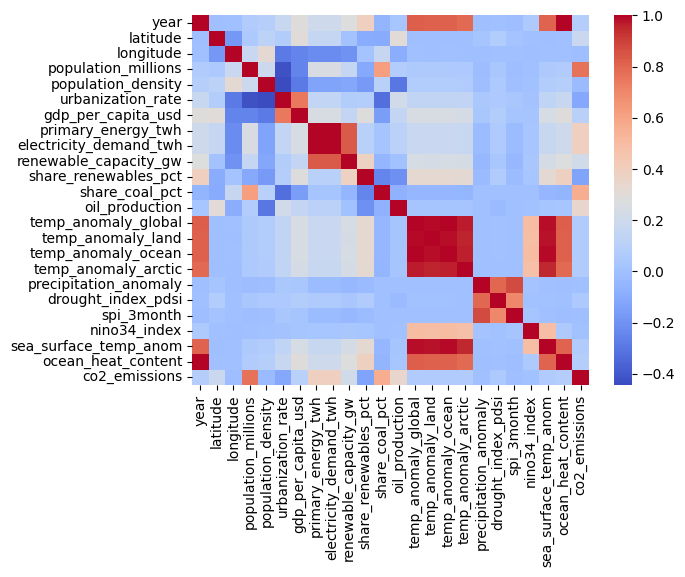

In [7]:
corr_matrix = df_cleaned.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap="coolwarm")

In [8]:
sorted_corr_target = corr_matrix[TARGET].sort_values(ascending=False, key=abs)
sorted_corr_target

co2_emissions             1.000000
population_millions       0.766923
share_coal_pct            0.564598
primary_energy_twh        0.394783
electricity_demand_twh    0.394783
oil_production            0.344945
renewable_capacity_gw     0.215388
latitude                  0.180420
share_renewables_pct     -0.132446
urbanization_rate        -0.113912
gdp_per_capita_usd        0.098381
year                      0.083329
ocean_heat_content        0.083108
temp_anomaly_ocean        0.069262
temp_anomaly_land         0.068725
sea_surface_temp_anom     0.068627
temp_anomaly_global       0.067878
temp_anomaly_arctic       0.064009
drought_index_pdsi        0.051349
population_density       -0.026515
longitude                -0.013083
spi_3month               -0.004862
nino34_index              0.003032
precipitation_anomaly    -0.000451
Name: co2_emissions, dtype: float64

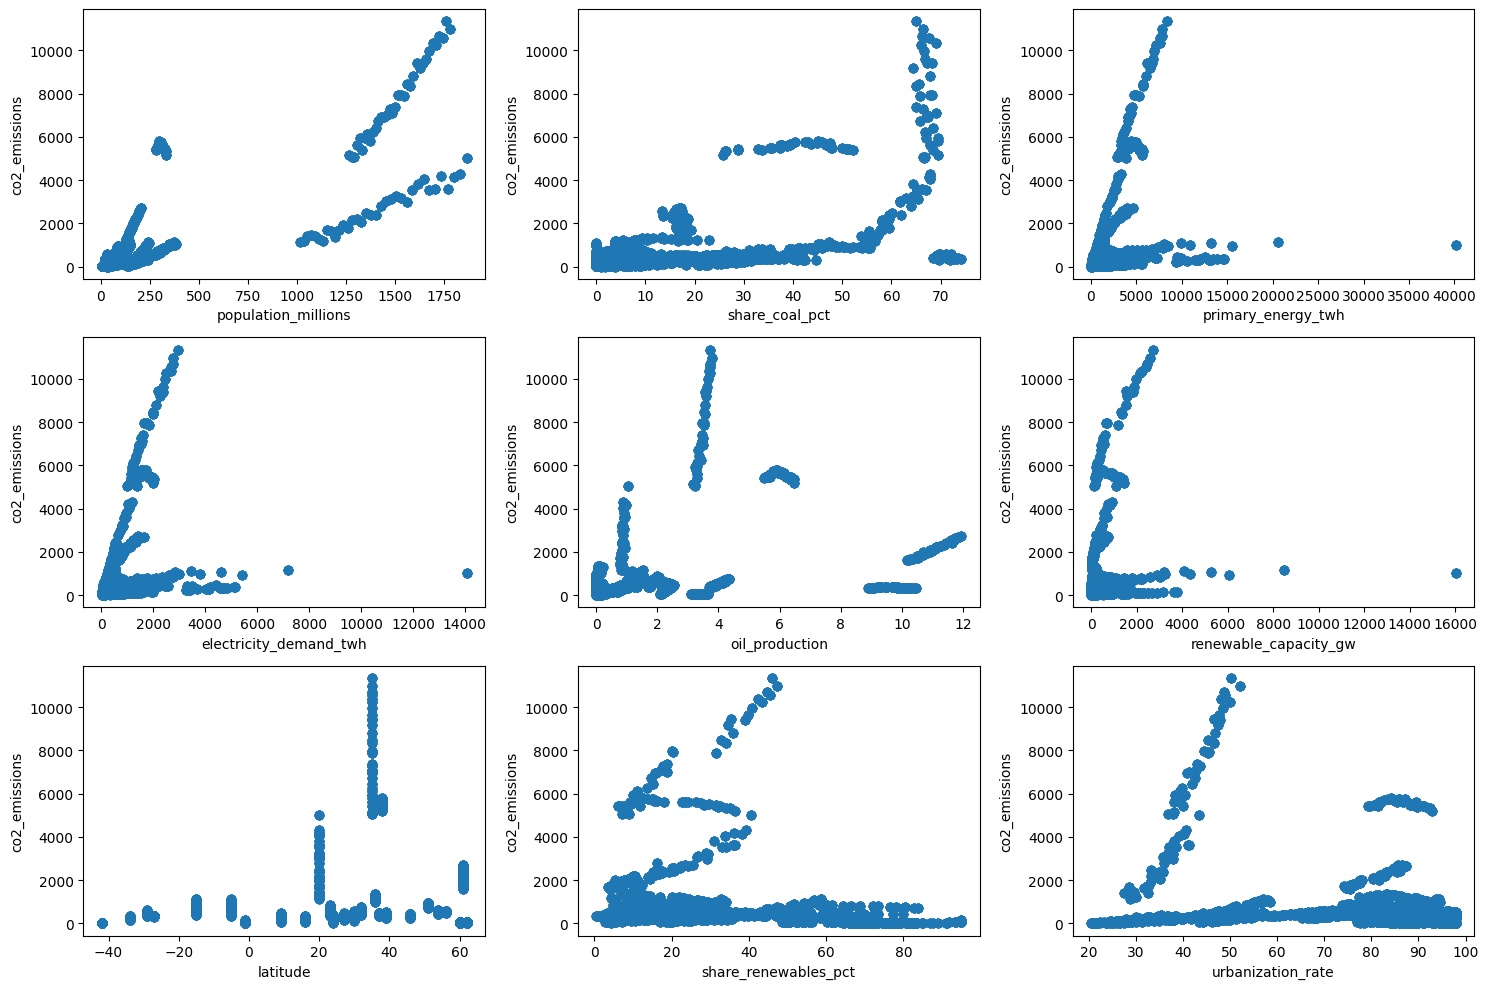

In [9]:
top9_cols = sorted_corr_target[1:10].index

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top9_cols):
    axes[i].scatter(df_cleaned[col], df_cleaned[TARGET], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)

plt.tight_layout()
plt.show()

### Features and Target Preparation

Prepare features and target for model training.

In [10]:
class OrdinalEncoder:
    def __init__(self, *, unknown_value=-1, unknown_key="<unk>"):
        self.categories_ = []
        self.features_ = None
        self._mappings = []
        self._inv_mappings = []
        if unknown_value >= 0:
            raise ValueError("unknown_value must be negative to avoid valid-code collisions.")
        self.unknown_value_ = unknown_value
        self.unknown_key_ = unknown_key

    def fit(self, X):
        self.categories_ = []
        self.features_ = X.columns
        self._mappings = []
        self._inv_mappings = []

        for col in range(len(X.columns)):
            col_categories = pd.unique(X.iloc[:, col])

            self.categories_.append(col_categories)

            mapping, inv_mapping = {}, {}
            for idx, category in enumerate(col_categories):
                mapping[category] = idx
                inv_mapping[idx] = category
            inv_mapping[-1] = self.unknown_key_

            self._mappings.append(mapping)
            self._inv_mappings.append(inv_mapping)
        return self

    def _t(self, X, mappings, na_fill_value):
        if not self.categories_:
            raise ValueError("Encoder has not been fitted.")
        if self.features_ is None or not self.features_.equals(X.columns):
            raise ValueError("Columns does not match fitted data.")

        X = X.copy()
        for i, col in enumerate(X.columns):
            X[col] = X[col].map(mappings[i]).fillna(na_fill_value)
        return X

    def transform(self, X):
        return self._t(X, self._mappings, self.unknown_value_).astype(int)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        return self._t(X, self._inv_mappings, self.unknown_key_)

In [11]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
        self.features_ = None

    def fit(self, X):
        self.mean_ = X.mean()
        self.std_ = X.std()
        self.features_ = X.columns
        return self

    def _check(self, X):
        if self.mean_ is None or self.std_ is None:
            raise ValueError("Encoder has not been fitted.")
        if self.features_ is None or not self.features_.equals(X.columns):
            raise ValueError("Columns does not match fitted data.")

    def transform(self, X):
        self._check(X)
        X = X.copy()
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X):
        self._check(X)
        X = X.copy()
        return X * self.std_ + self.mean_

In [12]:
numerical_features = df_cleaned.select_dtypes(include="number").columns
categorical_features = df_cleaned.select_dtypes(exclude="number").columns

numerical_features, categorical_features

(Index(['year', 'latitude', 'longitude', 'population_millions',
        'population_density', 'urbanization_rate', 'gdp_per_capita_usd',
        'primary_energy_twh', 'electricity_demand_twh', 'renewable_capacity_gw',
        'share_renewables_pct', 'share_coal_pct', 'oil_production',
        'temp_anomaly_global', 'temp_anomaly_land', 'temp_anomaly_ocean',
        'temp_anomaly_arctic', 'precipitation_anomaly', 'drought_index_pdsi',
        'spi_3month', 'nino34_index', 'sea_surface_temp_anom',
        'ocean_heat_content', 'co2_emissions'],
       dtype='str'),
 Index(['country', 'continent', 'income_group', 'latitude_band',
        'climate_zone'],
       dtype='str'))

In [13]:
df_train, df_test = df_cleaned[df_cleaned["year"] < 2010], df_cleaned[df_cleaned["year"] >= 2010]

df_train.shape, df_test.shape

((6096, 29), (4921, 29))

In [14]:
oe = OrdinalEncoder()
df_train[categorical_features] = oe.fit_transform(df_train[categorical_features])
df_test[categorical_features] = oe.transform(df_test[categorical_features])

ss = StandardScaler()
df_train[numerical_features] = ss.fit_transform(df_train[numerical_features])
df_test[numerical_features] = ss.transform(df_test[numerical_features])

### Building Model

Use python code to build your model. Give explanation on this process.


**Note: You are NOT allowed to use scikit-learn or any other library to build the machine learning model. You can only use linear regression or logistic regression model you learnt from DDW course.**

In [15]:
class LinearRegression:
    def __init__(self, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.weights_ = None
        self.history_ = []

    def _predict(self, X):
        return (X @ self.weights_).squeeze()

    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        return self._predict(X)

    def _cost(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad(self, X, y):
        n_samples, n_features = X.shape
        y_hat = self._predict(X)
        return (1 / n_samples) * X.T @ (y_hat - y)

    def fit(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))

        n_samples, n_features = X.shape
        self.weights_ = np.zeros((n_features,))
        self.history_ = []

        for _ in range(self.n_iters_):
            self.weights_ -= self.lr_ * self._cost_grad(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

        return self

In [16]:
X_train, y_train = df_train[FEATURES].to_numpy(), df_train[TARGET].to_numpy()
X_test, y_test = df_test[FEATURES].to_numpy(), df_test[TARGET].to_numpy()

In [17]:
lr = LinearRegression(n_iters=10000)
lr.fit(X_train, y_train)

Text(0, 0.5, 'Loss')

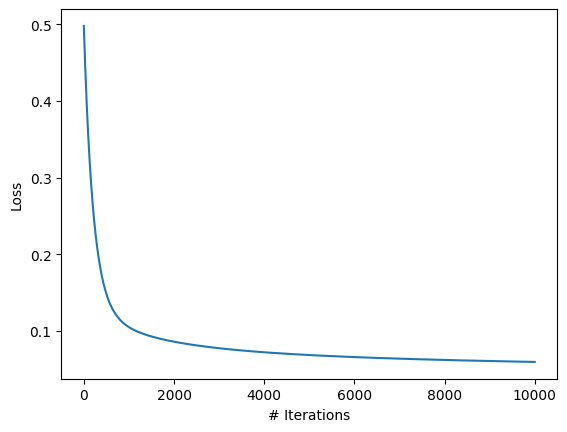

In [18]:
sns.lineplot(lr.history_)
plt.xlabel("# Iterations")
plt.ylabel("Loss")

In [19]:
feature_weight_pairs = list(zip(["<bias>", *FEATURES], lr.weights_.tolist()))
feature_weight_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

feature_weight_pairs

[('latitude_band', -0.43182988008714235),
 ('population_millions', 0.3795429548012317),
 ('oil_production', 0.31358227127227073),
 ('climate_zone', 0.2886550533081368),
 ('gdp_per_capita_usd', 0.256621122228384),
 ('share_coal_pct', 0.23082288292529757),
 ('<bias>', 0.19308335608241697),
 ('urbanization_rate', -0.16157651066512016),
 ('longitude', -0.15127076993694968),
 ('electricity_demand_twh', 0.13473755262535106),
 ('primary_energy_twh', 0.13473439267707119),
 ('continent', -0.0951694779646865),
 ('renewable_capacity_gw', -0.09162965365492003),
 ('share_renewables_pct', 0.06610685209010772),
 ('population_density', 0.033803728267704995),
 ('drought_index_pdsi', 0.024025290956867295),
 ('latitude', 0.019259958986078633),
 ('country', 0.014866646721184224),
 ('spi_3month', -0.012032624718420098),
 ('precipitation_anomaly', -0.009808653618194685),
 ('income_group', 0.009023773978769366),
 ('year', -0.008726505081578548),
 ('nino34_index', -0.00720789390610271),
 ('temp_anomaly_arctic

### Evaluating the Model

- Describe the metrics of your choice.
- Evaluate your model performance.

In [20]:
y_pred = lr.predict(X_test)

In [21]:
def r2_score(y_true, y_pred):
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true, axis=0)) ** 2))

In [22]:
def root_mean_squared_error(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2).tolist())

In [23]:
r2_score(y_test, y_pred), root_mean_squared_error(y_test, y_pred)

(0.8187328406952551, 0.3160552989025188)

In [24]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_model.score(X_test, y_test)

0.8155177700510067

### Improving the Model

- Improve the models by performing data processing techniques or hyperparameter tuning.
- You can repeat the steps above to show the improvement as compared to the previous performance.

*Note: changing or adding more dataset is not allowed.*

In [117]:
class LinearRegressionLayer:
    def __init__(self, n_in, n_out):
        self.learnable_ = True
        # He initialization: unscaled N(0, 1) weights blow up through 3 ReLU
        # layers (pre-activations grow ~sqrt(n_in) per layer), which explodes
        # the loss in the first few iterations and permanently kills most
        # ReLU units, collapsing the model to a near-constant prediction.
        self.weights_ = np.random.randn(n_out, n_in + 1) * np.sqrt(2 / n_in)
        self.input_ = None
        self.weights_gradient_ = None

    def forward(self, X):
        X = np.hstack((np.ones((X.shape[0], 1), dtype=X.dtype), X))
        self.input_ = X  # (n_samples, n_in + 1)
        return X @ self.weights_.T  # (n_samples, n_out)

    def backward(self, delta):  # (n_samples, n_out)
        self.weights_gradient_ = delta.T @ self.input_  # (n_out, n_in + 1)
        # Differentiate bias terms get 0
        return delta @ self.weights_[:, 1:]  # (n_samples, n_in)

In [118]:
class Relu:
    def __init__(self):
        self.learnable_ = False
        self.input_ = None

    def forward(self, X):  # (n_samples, n_in)
        self.input_ = X
        return np.maximum(0, X)

    def backward(self, delta):  # (n_samples, n_out)
        delta_relu = self.input_ > 0  # (n_samples, n_in)
        return delta * delta_relu  # Element-wise, n_in == n_out

In [119]:
class RegressiveMultilayerPerceptron:
    def __init__(self, layers, lr=0.001, n_iters=5000):
        self.lr_ = lr
        self.n_iters_ = n_iters
        self.layers_ = layers
        self.history_ = []

    def predict(self, X):
        cur = X
        for layer in self.layers_:
            cur = layer.forward(cur)
        return cur.squeeze(-1)  # (n_samples,)

    def _cost(self, X, y):  # Same as single layer
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return (1 / (2 * n_samples)) * np.sum((y_hat - y) ** 2)

    def _cost_grad_wrt_pred(self, X, y):
        n_samples, _ = X.shape
        y_hat = self.predict(X)
        return np.expand_dims((y_hat - y) / n_samples, axis=-1)  # (n_samples, 1)

    def _backpropagate(self, X, y):
        delta = self._cost_grad_wrt_pred(X, y)

        for layer in self.layers_[::-1]:
            delta = layer.backward(delta)
            if layer.learnable_:
                layer.weights_ -= self.lr_ * layer.weights_gradient_

    def fit(self, X, y):
        self.history_ = []

        for _ in range(self.n_iters_):
            self._backpropagate(X, y)

            cost = self._cost(X, y)
            self.history_.append(cost)

In [123]:
mlp = RegressiveMultilayerPerceptron([
    LinearRegressionLayer(X_train.shape[1], 16),
    Relu(),
    LinearRegressionLayer(16, 8),
    Relu(),
    LinearRegressionLayer(8, 1),
], lr=0.001, n_iters=50000)
mlp.fit(X_train, y_train)

In [125]:
y_pred_mlp = mlp.predict(X_test)

r2_score(y_test, y_pred_mlp), root_mean_squared_error(y_test, y_pred_mlp)

(0.9038517097300957, 0.1676430343851331)

Text(0, 0.5, 'Loss')

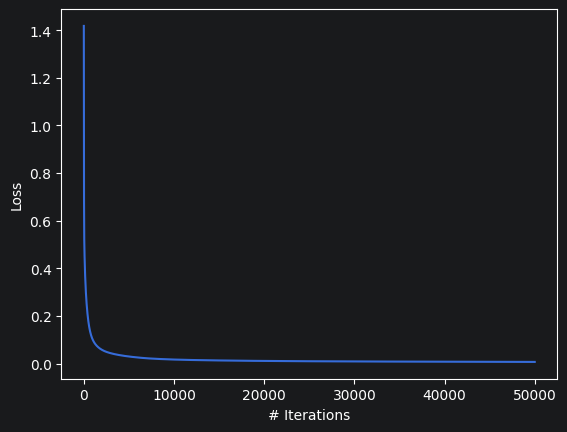

In [124]:
sns.lineplot(mlp.history_)
plt.xlabel("# Iterations")
plt.ylabel("Loss")

### Discussion and Analysis

- Analyze the results of your metrics.
- Explain how does your analysis and machine learning help to solve your problem statement.
- Conclusion.